In [8]:
# Block 1: Setup & Imports
!pip install mne numpy matplotlib scikit-learn -q

import os
import numpy as np
import matplotlib.pyplot as plt
import mne

mne.set_log_level('WARNING')  # keeps output clean, comment out if you want full logs

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [9]:
# Block 2: Load raw GDF file (starting with one subject, e.g. A01T.gdf)
data_path = r"D:\Download\eeg_conference\test_run_1\Dataset"
subject_file = os.path.join(data_path, "A01T.gdf")

raw = mne.io.read_raw_gdf(subject_file, preload=True)

# Quick inspection
print(raw.info)
print("Channel names:", raw.ch_names)
print("Sampling rate:", raw.info['sfreq'], "Hz")
print("Duration:", raw.times[-1], "seconds")

C:\Program Files\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>
Channel names: ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
Sampling rate: 250.0 Hz
Duration: 2690.108 seconds


In [10]:
# Block 3: Rename channels to standard 10-20 names + set channel types + montage

# Official BCI IV 2a channel order (22 EEG + 3 EOG), matching raw.ch_names order
channel_mapping = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4',
    'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2',
    'EEG-C4': 'C4', 'EEG-8': 'C6',
    'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
    'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz',
    'EOG-left': 'EOG-left', 'EOG-central': 'EOG-central', 'EOG-right': 'EOG-right'
}

raw.rename_channels(channel_mapping)

# Set correct channel types (needed so ICA/filtering treats EOG separately from EEG)
eog_channels = ['EOG-left', 'EOG-central', 'EOG-right']
channel_types = {ch: 'eog' for ch in eog_channels}
raw.set_channel_types(channel_types)

# Set standard 10-20 montage for the EEG channels (needed for topomaps/ICA visualization)
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='warn')

print(raw.info)
print("EEG channels:", len(mne.pick_types(raw.info, eeg=True)))
print("EOG channels:", len(mne.pick_types(raw.info, eog=True)))

<Info | 9 non-empty values
 bads: []
 ch_names: Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, ...
 chs: 22 EEG, 3 EOG
 custom_ref_applied: False
 dig: 25 items (3 Cardinal, 22 EEG)
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>
EEG channels: 22
EOG channels: 3


C:\Users\alok_\AppData\Local\Temp\ipykernel_17584\703118110.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


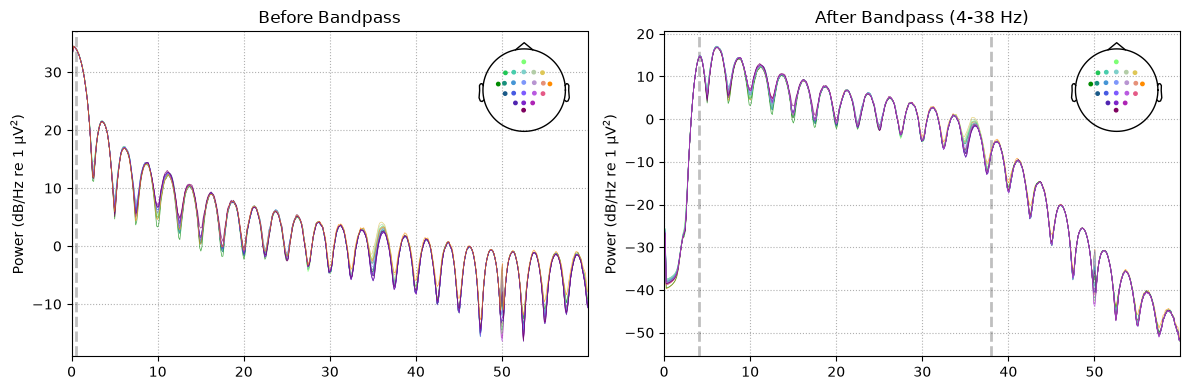

In [11]:
# Block 4: Bandpass filter (motor imagery relevant frequency range)

l_freq = 4.0   # lower cutoff
h_freq = 38.0  # upper cutoff

raw_filtered = raw.copy().filter(
    l_freq=l_freq,
    h_freq=h_freq,
    picks='eeg',          # only filter EEG channels, leave EOG as-is for now (needed raw for ICA detection)
    method='iir',
    iir_params=dict(order=4, ftype='butter'),
    verbose=False
)

# Quick visual check: PSD before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw.compute_psd(picks='eeg', fmax=60).plot(axes=axes[0], show=False)
axes[0].set_title('Before Bandpass')
raw_filtered.compute_psd(picks='eeg', fmax=60).plot(axes=axes[1], show=False)
axes[1].set_title('After Bandpass (4-38 Hz)')
plt.tight_layout()
plt.show()

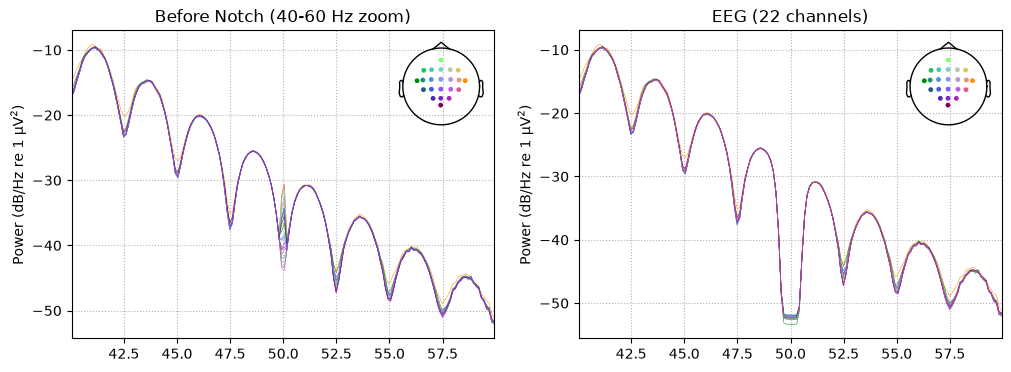

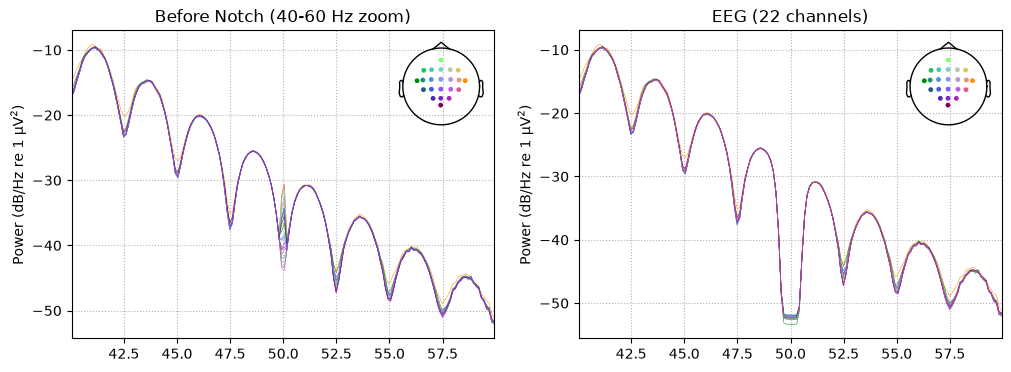

In [12]:
# Block 5: Notch filter for powerline noise

notch_freq = 50.0  # BCI IV 2a recorded in Austria -> 50 Hz mains (use 60.0 if your setup is US-based)

raw_notched = raw_filtered.copy().notch_filter(
    freqs=notch_freq,
    picks='eeg',
    method='iir',
    verbose=False
)

# Visual check: zoom into 45-55 Hz range to see if the spike is gone
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_filtered.compute_psd(picks='eeg', fmin=40, fmax=60).plot(axes=axes[0], show=False)
axes[0].set_title('Before Notch (40-60 Hz zoom)')
raw_notched.compute_psd(picks='eeg', fmin=40, fmax=60).plot(axes=axes[1], show=False)

Detected EOG-related components: [np.int64(0), np.int64(15)]


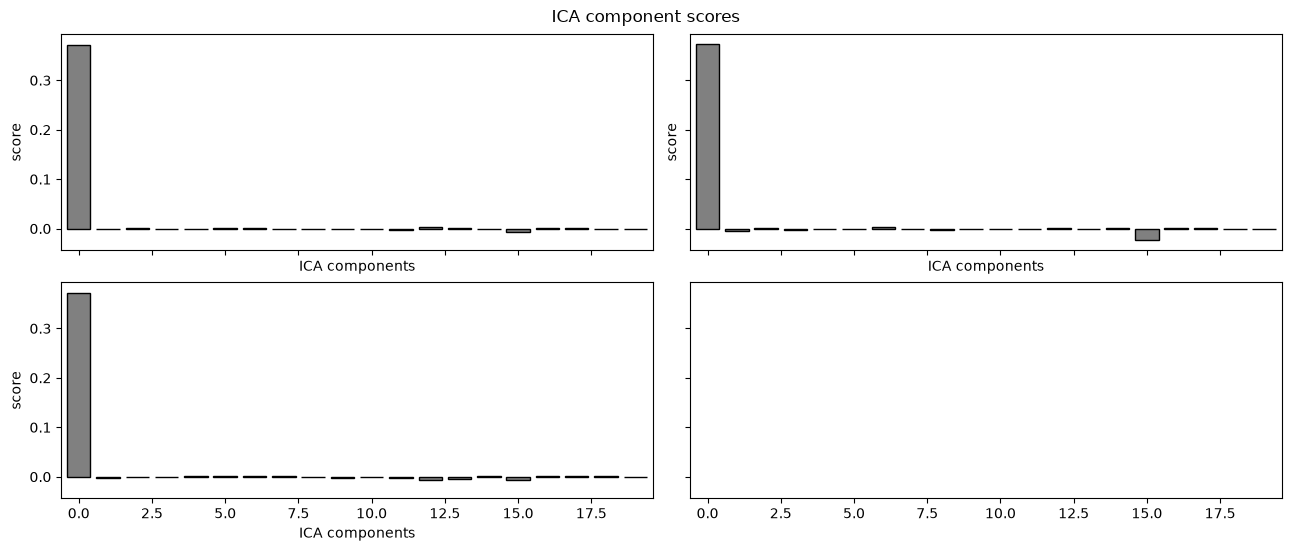

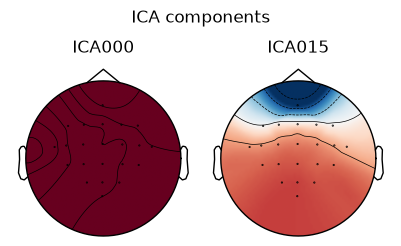

In [14]:
# Block 6 fix: ICA visualization (no duplicates)
eog_indices, eog_scores = ica.find_bads_eog(raw_notched)
print("Detected EOG-related components:", eog_indices)

fig1 = ica.plot_scores(eog_scores, show=False)
plt.show()
plt.close(fig1)

fig2 = ica.plot_components(picks=eog_indices, show=False)
plt.show()
plt.close(fig2)

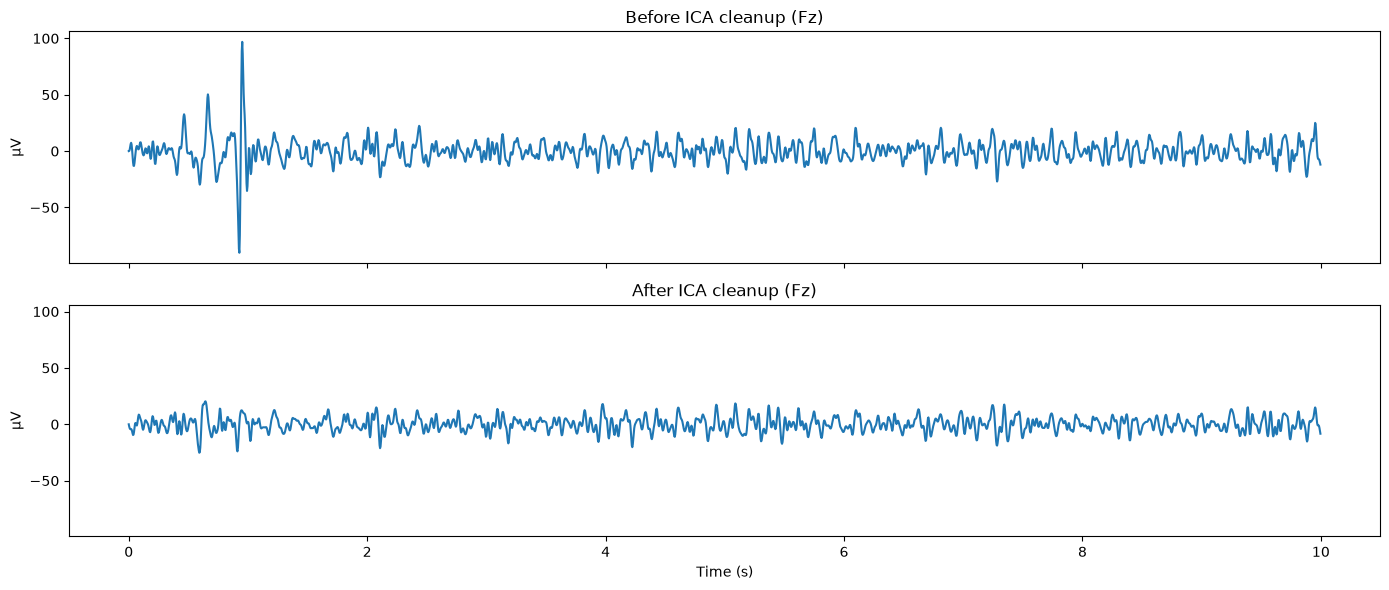

In [16]:
# Block 7 fix: manual plot for before/after comparison (raw.plot() doesn't support axes=)

sfreq = raw_clean.info['sfreq']
duration = 10  # seconds
start = 0
n_samples = int(duration * sfreq)

ch_idx = raw_clean.ch_names.index('Fz')

data_before, times = raw_notched[ch_idx, start:start+n_samples]
data_after, _ = raw_clean[ch_idx, start:start+n_samples]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
axes[0].plot(times, data_before[0] * 1e6)  # convert V to µV
axes[0].set_title('Before ICA cleanup (Fz)')
axes[0].set_ylabel('µV')

axes[1].plot(times, data_after[0] * 1e6)
axes[1].set_title('After ICA cleanup (Fz)')
axes[1].set_ylabel('µV')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()
plt.close(fig)

In [17]:
# Block 8: Full preprocessing pipeline as a reusable function

channel_mapping = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4',
    'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2',
    'EEG-C4': 'C4', 'EEG-8': 'C6',
    'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
    'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz',
    'EOG-left': 'EOG-left', 'EOG-central': 'EOG-central', 'EOG-right': 'EOG-right'
}

def preprocess_subject(file_path, l_freq=4.0, h_freq=38.0, notch=50.0, n_components=20, verbose=False):
    """
    Runs full preprocessing pipeline on one GDF file:
    load -> rename channels -> bandpass -> notch -> ICA
    Returns cleaned raw object, or None if it fails.
    """
    try:
        # Load
        raw = mne.io.read_raw_gdf(file_path, preload=True, verbose=verbose)

        # Rename + set channel types + montage
        raw.rename_channels(channel_mapping)
        eog_channels = ['EOG-left', 'EOG-central', 'EOG-right']
        raw.set_channel_types({ch: 'eog' for ch in eog_channels})
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='warn', verbose=verbose)

        # Bandpass
        raw.filter(l_freq=l_freq, h_freq=h_freq, picks='eeg',
                   method='iir', iir_params=dict(order=4, ftype='butter'), verbose=verbose)

        # Notch
        raw.notch_filter(freqs=notch, picks='eeg', method='iir', verbose=verbose)

        # ICA
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=RANDOM_SEED,
                                     method='fastica', max_iter='auto', verbose=verbose)
        ica.fit(raw, picks='eeg', verbose=verbose)
        eog_indices, eog_scores = ica.find_bads_eog(raw, verbose=verbose)
        ica.exclude = eog_indices
        ica.apply(raw, verbose=verbose)

        print(f"  {os.path.basename(file_path)}: OK — excluded ICA components {eog_indices}")
        return raw

    except Exception as e:
        print(f"  {os.path.basename(file_path)}: FAILED — {e}")
        return None

In [19]:
# Block 9: Run pipeline on all 18 files (9 subjects x 2 sessions)

data_path = r"D:\Download\eeg_conference\test_run_1\Dataset"
subjects = [f"{i:02d}" for i in range(1, 10)]  # '01' to '09'
sessions = ['T', 'E']

cleaned_data = {}  # key: 'A01T', value: cleaned raw object
failed_files = []

for subj in subjects:
    for sess in sessions:
        fname = f"A{subj}{sess}.gdf"
        fpath = os.path.join(data_path, fname)

        if not os.path.exists(fpath):
            print(f"  {fname}: NOT FOUND, skipping")
            failed_files.append(fname)
            continue

        print(f"Processing {fname}...")
        raw_clean = preprocess_subject(fpath)

        if raw_clean is not None:
            cleaned_data[f"A{subj}{sess}"] = raw_clean
        else:
            failed_files.append(fname)

print(f"\nDone. Successfully processed: {len(cleaned_data)}/18")
print(f"Failed/missing: {failed_files}")

Processing A01T.gdf...


C:\Program Files\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  A01T.gdf: OK — excluded ICA components [np.int64(0), np.int64(15)]
Processing A01E.gdf...


C:\Program Files\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  A01E.gdf: OK — excluded ICA components [np.int64(0), np.int64(16), np.int64(12)]
Processing A02T.gdf...


...

  A08E.gdf: OK — excluded ICA components [np.int64(0), np.int64(18)]
Processing A09T.gdf...


C:\Program Files\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  A09T.gdf: OK — excluded ICA components [np.int64(0), np.int64(16)]
Processing A09E.gdf...


C:\Program Files\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  A09E.gdf: OK — excluded ICA components [np.int64(0), np.int64(17)]

Done. Successfully processed: 18/18
Failed/missing: []


In [20]:
# Block 10: Save all cleaned raws as .fif files

output_dir = os.path.join(data_path, "cleaned")
os.makedirs(output_dir, exist_ok=True)

for key, raw_clean in cleaned_data.items():
    out_path = os.path.join(output_dir, f"{key}_clean_raw.fif")
    raw_clean.save(out_path, overwrite=True)
    print(f"Saved: {out_path}")

print(f"\nAll {len(cleaned_data)} files saved to {output_dir}")

Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A01T_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A01E_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A02T_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A02E_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A03T_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A03E_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A04T_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A04E_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A05T_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A05E_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A06T_clean_raw.fif
Saved: D:\Download\eeg_conference\test_run_1\Dataset\cleaned\A06E_clean_raw.fif
Saved: D:\Download\eeg_conference\test_r